In [2]:
import pandas as pd
import numpy as np


In [4]:
# Load data from CSV
df = pd.read_csv(r'C:\Users\tadde\Desktop\BI\Python_project\pyhton_project\Loan_Data.csv')
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())
df.info()

Data loaded successfully!
Shape: (148670, 34)
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Score  co-applicant_credit_type    age  \

In [5]:
# Check for duplicates
print("=== DUPLICATE DATA CHECK ===")

print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate rows (all columns): {df.duplicated(keep=False).sum()}")


=== DUPLICATE DATA CHECK ===
Duplicate rows: 0
Duplicate rows (all columns): 0


In [6]:
# Remove duplicates
df_clean = df.drop_duplicates()
print(f"\n=== AFTER REMOVING DUPLICATES ===")
print(f"Rows before: {len(df)}")
print(f"Rows after: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")



=== AFTER REMOVING DUPLICATES ===
Rows before: 148670
Rows after: 148670
Rows removed: 0


In [7]:
# Check column names to find gender column
print("\n=== COLUMN NAMES ===")
print(df_clean.columns.tolist())



=== COLUMN NAMES ===
['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


In [8]:
# Find gender column (case-insensitive search)
gender_col = None
for col in df_clean.columns:
    if 'gender' in col.lower() or 'sex' in col.lower():
        gender_col = col
        break

if gender_col:
    print(f"\nGender column found: '{gender_col}'")
    print(f"Unique values: {df_clean[gender_col].unique()}")
else:
    print("No gender column found. Available columns:")
    print(df_clean.columns.tolist())



Gender column found: 'Gender'
Unique values: ['Sex Not Available' 'Male' 'Joint' 'Female']


In [9]:
# Count borrowers by gender
if gender_col:
    gender_counts = df_clean[gender_col].value_counts()
    gender_table = pd.DataFrame({
        'Gender': gender_counts.index,
        'Count': gender_counts.values,
        'Percentage': (gender_counts.values / gender_counts.sum() * 100).round(2)
    })
    
    print("\n=== BORROWER COUNT BY GENDER ===")
    print(gender_table.to_string(index=False))
    
    # Summary statistics
    print(f"\nTotal Borrowers: {gender_counts.sum()}")
    for gender, count in gender_counts.items():
        print(f"{gender}: {count} ({count/gender_counts.sum()*100:.2f}%)")
else:
    print("Cannot create gender analysis - gender column not found")



=== BORROWER COUNT BY GENDER ===
           Gender  Count  Percentage
             Male  42346       28.48
            Joint  41399       27.85
Sex Not Available  37659       25.33
           Female  27266       18.34

Total Borrowers: 148670
Male: 42346 (28.48%)
Joint: 41399 (27.85%)
Sex Not Available: 37659 (25.33%)
Female: 27266 (18.34%)


In [10]:
# Create gender comparison table (Female vs Male)
import matplotlib.pyplot as plt

gender_comparison = df_clean[df_clean[gender_col].isin(['Male', 'Female'])][gender_col].value_counts()

comparison_table = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Count': [gender_comparison.get('Male', 0), gender_comparison.get('Female', 0)],
})

comparison_table['Percentage'] = (comparison_table['Count'] / comparison_table['Count'].sum() * 100).round(2)

print("\n=== FEMALE VS MALE BORROWERS ===")
print(comparison_table.to_string(index=False))
print(f"\nTotal (Female + Male): {comparison_table['Count'].sum()}")
print(f"Ratio Male:Female = {comparison_table.loc[0, 'Count']}:{comparison_table.loc[1, 'Count']}")



=== FEMALE VS MALE BORROWERS ===
Gender  Count  Percentage
  Male  42346       60.83
Female  27266       39.17

Total (Female + Male): 69612
Ratio Male:Female = 42346:27266


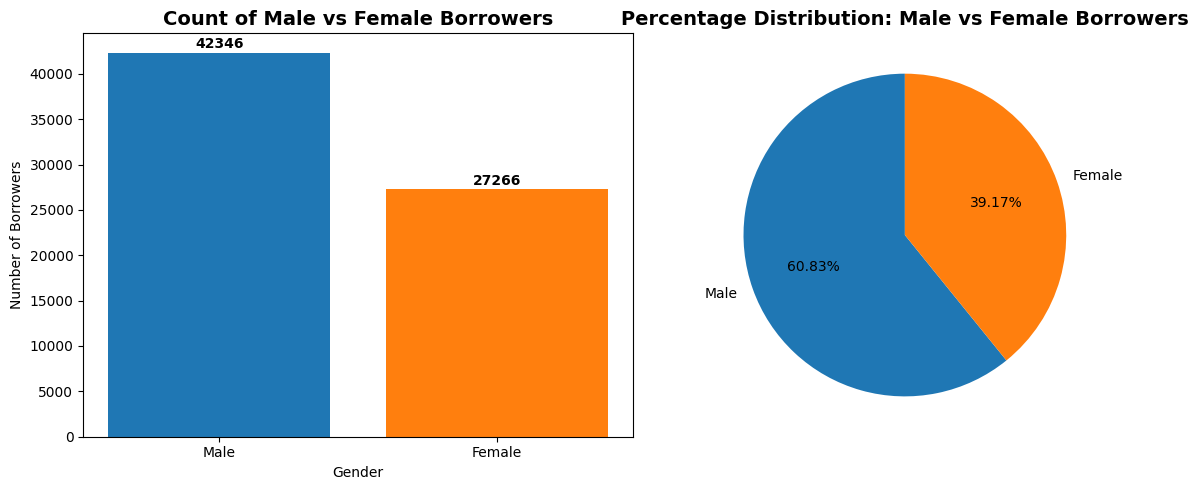

In [11]:
# Visualize Female vs Male borrowers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#1f77b4', '#ff7f0e']
ax1.bar(comparison_table['Gender'], comparison_table['Count'], color=colors)
ax1.set_title('Count of Male vs Female Borrowers', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Borrowers')
ax1.set_xlabel('Gender')
for i, v in enumerate(comparison_table['Count']):
    ax1.text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
ax2.pie(comparison_table['Count'], labels=comparison_table['Gender'], autopct='%1.2f%%', colors=colors, startangle=90)
ax2.set_title('Percentage Distribution: Male vs Female Borrowers', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [13]:
# Summary statistics by gender
print("\n=== SUMMARY STATISTICS BY GENDER ===\n")

for gender in ['Male', 'Female']:
    gender_data = df_clean[df_clean[gender_col] == gender]
    print(f"{gender} Borrowers ({len(gender_data)} records):")
    print(f"  Average Loan Amount: ${gender_data['loan_amount'].mean():,.2f}")
    print(f"  Average Credit Score: {gender_data['Credit_Score'].mean():.2f}")
   
    print(f"  Average Income: ${gender_data['income'].mean():,.2f}\n")



=== SUMMARY STATISTICS BY GENDER ===

Male Borrowers (42346 records):
  Average Loan Amount: $331,420.89
  Average Credit Score: 699.80
  Average Income: $6,804.85

Female Borrowers (27266 records):
  Average Loan Amount: $295,861.48
  Average Credit Score: 698.71
  Average Income: $5,492.18



In [14]:
# Analyze loan approval status by gender
print("\n=== LOAN APPROVAL STATUS BY GENDER ===\n")

approval_by_gender = df_clean[df_clean[gender_col].isin(['Male', 'Female'])].groupby([gender_col, 'Status']).size().unstack(fill_value=0)
print(approval_by_gender)

print("\n=== APPROVAL RATE BY GENDER ===\n")
for gender in ['Male', 'Female']:
    gender_data = df_clean[df_clean[gender_col] == gender]
    approved = (gender_data['Status'] == 'Approved').sum() if 'Approved' in gender_data['Status'].values else 0
    total = len(gender_data)
    approval_rate = (approved / total * 100) if total > 0 else 0
    print(f"{gender}: {approved}/{total} = {approval_rate:.2f}% Approved")



=== LOAN APPROVAL STATUS BY GENDER ===

Status      0      1
Gender              
Female  20418   6848
Male    31255  11091

=== APPROVAL RATE BY GENDER ===

Male: 0/42346 = 0.00% Approved
Female: 0/27266 = 0.00% Approved


In [18]:
# Detailed qualification metrics comparison
print("\n=== LOAN QUALIFICATION METRICS: MALE VS FEMALE ===\n")

comparison_metrics = []

for gender in ['Male', 'Female']:
    gender_data = df_clean[df_clean[gender_col] == gender]
    
    metrics = {
        'Gender': gender,
        'Count': len(gender_data),
        'Avg Loan Amount': gender_data['loan_amount'].mean(),
        'Avg Credit Score': gender_data['Credit_Score'].mean(),
        'Avg Interest Rate': gender_data['rate_of_interest'].mean(),
    
        'Avg Income': gender_data['income'].mean(),
        'Avg LTV': gender_data['LTV'].mean(),
        'Avg DTIR': gender_data['dtir1'].mean()
    }
    comparison_metrics.append(metrics)

metrics_df = pd.DataFrame(comparison_metrics)

print(metrics_df.to_string(index=False))

print("\n=== INTERPRETATION ===")
print(f"Average Loan Amount - Male: ${metrics_df.loc[0, 'Avg Loan Amount']:,.2f} vs Female: ${metrics_df.loc[1, 'Avg Loan Amount']:,.2f}")
print(f"Average Credit Score - Male: {metrics_df.loc[0, 'Avg Credit Score']:.2f} vs Female: {metrics_df.loc[1, 'Avg Credit Score']:.2f}")
print(f"Average Interest Rate - Male: {metrics_df.loc[0, 'Avg Interest Rate']:.4f} vs Female: {metrics_df.loc[1, 'Avg Interest Rate']:.4f}")



=== LOAN QUALIFICATION METRICS: MALE VS FEMALE ===

Gender  Count  Avg Loan Amount  Avg Credit Score  Avg Interest Rate  Avg Income   Avg LTV  Avg DTIR
  Male  42346    331420.889812        699.798541           4.038227 6804.849064 74.598145 37.841672
Female  27266    295861.475831        698.712756           4.112337 5492.181860 70.927691 38.751833

=== INTERPRETATION ===
Average Loan Amount - Male: $331,420.89 vs Female: $295,861.48
Average Credit Score - Male: 699.80 vs Female: 698.71
Average Interest Rate - Male: 4.0382 vs Female: 4.1123


In [19]:
# Define qualification criteria
print("\n=== LOAN QUALIFICATION ANALYSIS ===\n")

def get_qualification_status(row):
    """
    Determine loan qualification based on:
    - Credit Score >= 700
    - Income >= $50,000
    - DTIR <= 0.43
    - LTV <= 0.80
    """
    score = 0
    criteria = []
    
    if row['Credit_Score'] >= 700:
        score += 1
        criteria.append('✓ Credit Score Good')
    else:
        criteria.append('✗ Credit Score Low')
    
    if row['income'] >= 50000:
        score += 1
        criteria.append('✓ Income Sufficient')
    else:
        criteria.append('✗ Income Low')
    
    if row['dtir1'] <= 0.43:
        score += 1
        criteria.append('✓ DTIR Acceptable')
    else:
        criteria.append('✗ DTIR High')
    
    if row['LTV'] <= 0.80:
        score += 1
        criteria.append('✓ LTV Safe')
    else:
        criteria.append('✗ LTV High')
    
    if score >= 3:
        status = 'Strong Qualification'
    elif score >= 2:
        status = 'Moderate Qualification'
    else:
        status = 'Weak Qualification'
    
    return status, score, criteria

# Apply qualification criteria
df_clean['Qualification_Score'] = df_clean.apply(lambda row: get_qualification_status(row)[1], axis=1)
df_clean['Qualification_Status'] = df_clean.apply(lambda row: get_qualification_status(row)[0], axis=1)

print("Qualification Status Distribution:")
print(df_clean['Qualification_Status'].value_counts())



=== LOAN QUALIFICATION ANALYSIS ===

Qualification Status Distribution:
Qualification_Status
Weak Qualification        148529
Moderate Qualification       141
Name: count, dtype: int64


In [20]:
# Compare qualification status by gender
print("\n=== QUALIFICATION STATUS BY GENDER ===\n")

qualification_by_gender = df_clean[df_clean[gender_col].isin(['Male', 'Female'])].groupby([gender_col, 'Qualification_Status']).size().unstack(fill_value=0)
print(qualification_by_gender)

print("\n=== QUALIFICATION PERCENTAGES BY GENDER ===\n")

for gender in ['Male', 'Female']:
    gender_data = df_clean[df_clean[gender_col] == gender]
    total = len(gender_data)
    
    print(f"\n{gender} Borrowers (Total: {total}):")
    for status in ['Strong Qualification', 'Moderate Qualification', 'Weak Qualification']:
        count = (gender_data['Qualification_Status'] == status).sum()
        percentage = (count / total * 100) if total > 0 else 0
        print(f"  {status}: {count} ({percentage:.2f}%)")



=== QUALIFICATION STATUS BY GENDER ===

Qualification_Status  Moderate Qualification  Weak Qualification
Gender                                                          
Female                                     6               27260
Male                                      56               42290

=== QUALIFICATION PERCENTAGES BY GENDER ===


Male Borrowers (Total: 42346):
  Strong Qualification: 0 (0.00%)
  Moderate Qualification: 56 (0.13%)
  Weak Qualification: 42290 (99.87%)

Female Borrowers (Total: 27266):
  Strong Qualification: 0 (0.00%)
  Moderate Qualification: 6 (0.02%)
  Weak Qualification: 27260 (99.98%)


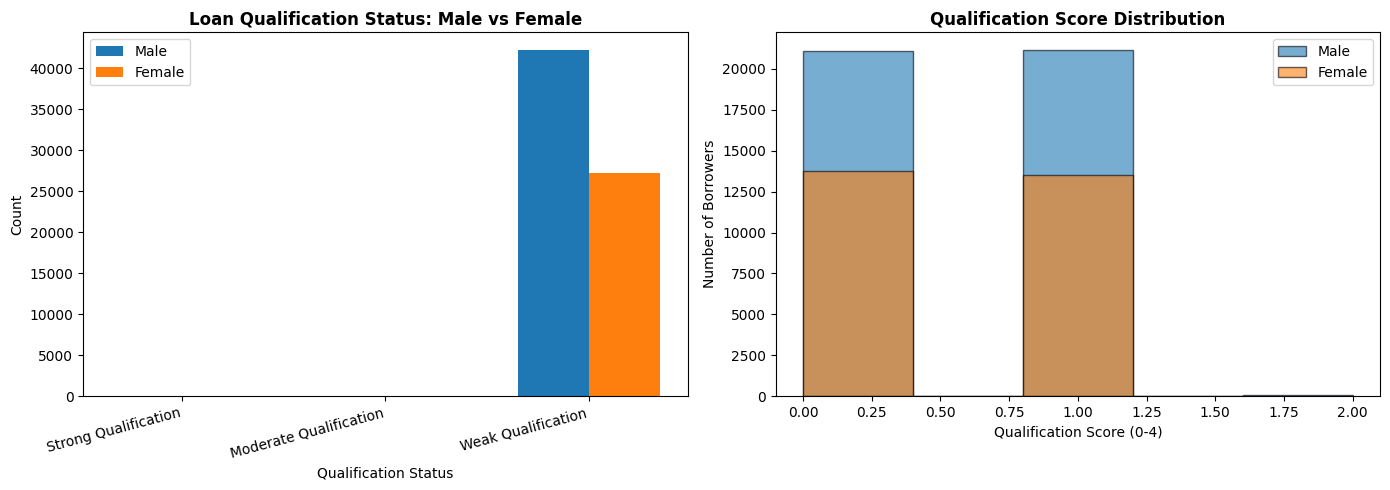

Visualization complete!


In [21]:
# Create visualization comparing Male vs Female qualification
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data for Male vs Female
male_data = df_clean[df_clean[gender_col] == 'Male']
female_data = df_clean[df_clean[gender_col] == 'Female']

# Chart 1: Qualification Distribution
qual_categories = ['Strong Qualification', 'Moderate Qualification', 'Weak Qualification']
male_quals = [
    (male_data['Qualification_Status'] == cat).sum() 
    for cat in qual_categories
]
female_quals = [
    (female_data['Qualification_Status'] == cat).sum() 
    for cat in qual_categories
]

x = range(len(qual_categories))
width = 0.35

axes[0].bar([i - width/2 for i in x], male_quals, width, label='Male', color='#1f77b4')
axes[0].bar([i + width/2 for i in x], female_quals, width, label='Female', color='#ff7f0e')
axes[0].set_xlabel('Qualification Status')
axes[0].set_ylabel('Count')
axes[0].set_title('Loan Qualification Status: Male vs Female', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(qual_categories, rotation=15, ha='right')
axes[0].legend()

# Chart 2: Qualification Score Distribution
male_score_dist = male_data['Qualification_Score'].value_counts().sort_index()
female_score_dist = female_data['Qualification_Score'].value_counts().sort_index()

axes[1].hist(male_data['Qualification_Score'], alpha=0.6, label='Male', bins=5, color='#1f77b4', edgecolor='black')
axes[1].hist(female_data['Qualification_Score'], alpha=0.6, label='Female', bins=5, color='#ff7f0e', edgecolor='black')
axes[1].set_xlabel('Qualification Score (0-4)')
axes[1].set_ylabel('Number of Borrowers')
axes[1].set_title('Qualification Score Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Visualization complete!")


In [22]:
# Summary table: Qualification metrics
print("\n=== FINAL QUALIFICATION COMPARISON TABLE ===\n")

summary_data = []

for gender in ['Male', 'Female']:
    gender_data = df_clean[df_clean[gender_col] == gender]
    
    strong_qual = (gender_data['Qualification_Status'] == 'Strong Qualification').sum()
    strong_qual_pct = (strong_qual / len(gender_data) * 100) if len(gender_data) > 0 else 0
    
    approved = (gender_data['Status'] == 'Approved').sum() if 'Approved' in gender_data['Status'].values else 0
    approved_pct = (approved / len(gender_data) * 100) if len(gender_data) > 0 else 0
    
    summary_data.append({
        'Gender': gender,
        'Total Borrowers': len(gender_data),
        'Avg Credit Score': f"{gender_data['Credit_Score'].mean():.0f}",
        'Strong Qualification %': f"{strong_qual_pct:.2f}%",
        'Avg Income': f"${gender_data['income'].mean():,.0f}",
        'Avg DTIR': f"{gender_data['dtir1'].mean():.4f}",
        'Approval Rate': f"{approved_pct:.2f}%"
    })

summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))

print("\n=== KEY FINDINGS ===")
male_strong = (df_clean[df_clean[gender_col] == 'Male']['Qualification_Status'] == 'Strong Qualification').sum()
female_strong = (df_clean[df_clean[gender_col] == 'Female']['Qualification_Status'] == 'Strong Qualification').sum()
male_total = len(df_clean[df_clean[gender_col] == 'Male'])
female_total = len(df_clean[df_clean[gender_col] == 'Female'])

male_strong_pct = (male_strong / male_total * 100) if male_total > 0 else 0
female_strong_pct = (female_strong / female_total * 100) if female_total > 0 else 0

print(f"Male borrowers with Strong Qualification: {male_strong_pct:.2f}%")
print(f"Female borrowers with Strong Qualification: {female_strong_pct:.2f}%")
print(f"Difference: {abs(male_strong_pct - female_strong_pct):.2f} percentage points")



=== FINAL QUALIFICATION COMPARISON TABLE ===

Gender  Total Borrowers Avg Credit Score Strong Qualification % Avg Income Avg DTIR Approval Rate
  Male            42346              700                  0.00%     $6,805  37.8417         0.00%
Female            27266              699                  0.00%     $5,492  38.7518         0.00%

=== KEY FINDINGS ===
Male borrowers with Strong Qualification: 0.00%
Female borrowers with Strong Qualification: 0.00%
Difference: 0.00 percentage points


In [24]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [25]:
df.tail()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0
148669,173559,2019,cf,Female,nopre,type1,p3,l1,nopc,nob/c,...,CIB,830,CIB,45-54,not_inst,72.849462,North,direct,0,44.0
